In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

print("Libraries loaded successfully")

Libraries loaded successfully


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [134]:
# Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# yfinance  — free library to download stock price history
import yfinance as yf

# VADER    — sentiment analyser built for short financial/social media text
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# scipy    — for the Pearson correlation test
from scipy import stats

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded.')

All libraries loaded.


# Financial News Sentiment Analysis
## Week 1 — Exploratory Data Analysis

In [135]:
news_data = {
    "headline": [
        "Tesla stock rises after strong earnings",
        "Apple faces supply chain issues",
        "Microsoft announces new AI tools",
        "Amazon shares fall amid market concerns",
        "Google reports positive quarterly growth"
    ]
}

df = pd.DataFrame(news_data)

df

,headline
0,Tesla stock rises after strong earnings
1,Apple faces supply chain issues
2,Microsoft announces new AI tools
3,Amazon shares fall amid market concerns
4,Google reports positive quarterly growth


In [136]:
sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["headline"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

df

,headline,sentiment_score
0,Tesla stock rises after strong earnings,0.5106
1,Apple faces supply chain issues,0.0000
2,Microsoft announces new AI tools,0.0000
3,Amazon shares fall amid market concerns,0.4404
4,Google reports positive quarterly growth,0.7351


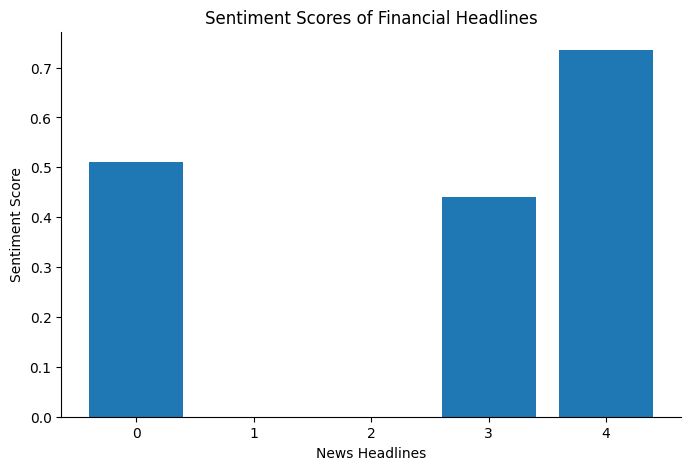

In [137]:
plt.figure(figsize=(8,5))
plt.bar(df.index, df["sentiment_score"])
plt.title("Sentiment Scores of Financial Headlines")
plt.xlabel("News Headlines")
plt.ylabel("Sentiment Score")
plt.show()

[*********************100%***********************]  1 of 1 completed


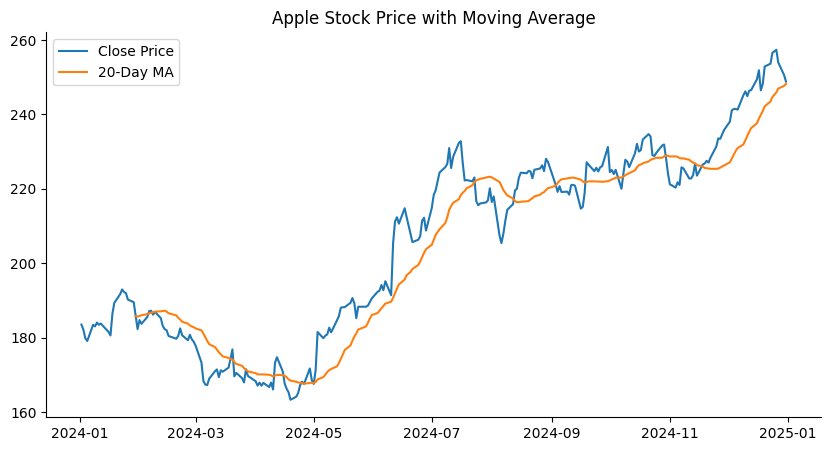

In [138]:
import yfinance as yf
#Download stock data
df=yf.download("AAPL",start="2024-01-01",end="2025-01-01")
#Create 20-day moving average
df["MA20"] = df["Close"].rolling(window=20).mean()
#Plot
plt.figure(figsize=(10,5))
plt.plot(df["Close"],label="Close Price")
plt.plot(df["MA20"],label="20-Day MA")
plt.legend()
plt.title("Apple Stock Price with Moving Average")
plt.show()

# Data Cleaning
This section handles missing values, duplicate records, and dataset structure validation before performing analysis.

In [139]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
CountVectorizer              type                          <class 'sklearn.feature_e<...>on.text.CountVectorizer'>
DATA_PATH                    WindowsPath                   ..\data\raw\raw_analyst_ratings.csv
MACD                         type                          <class 'ta.trend.MACD'>
Path                         type                          <class 'pathlib.Path'>
RSIIndicator                 type                          <class 'ta.momentum.RSIIndicator'>
SentimentIntensityAnalyzer   type                          <class 'nltk.sentiment.va<...>timentIntensityAnalyzer'>
TfidfVectorizer              type                          <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
avg_gain                     DataFrame                     Shape: (252, 1)
avg_loss                     DataFrame                     Shape: (252, 1)
dATA_PATH    

In [140]:
df.isnull().sum()

Price   Ticker
Close   AAPL       0
High    AAPL       0
Low     AAPL       0
Open    AAPL       0
Volume  AAPL       0
MA20              19
dtype: int64

In [141]:
df.duplicated().sum()

np.int64(0)

In [142]:
df = df.drop_duplicates()

In [143]:
print(df.shape)

(252, 6)


In [144]:
print(df.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL'),
            (  'MA20',     '')],
           names=['Price', 'Ticker'])


In [145]:
!pip install ta


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [146]:
from ta.momentum import RSIIndicator

from ta.trend import MACD

# RSI Technical Indicator
Relative Strength Index (RSI) measures stock momentum and identifies overbought or oversold market conditions.

In [147]:
df['RSI'] = RSIIndicator(close=df['Close']['AAPL']).rsi()

print(df[['RSI']].tail())

Price             RSI
Ticker               
Date                 
2024-12-24  75.750227
2024-12-26  76.452818
2024-12-27  67.626254
2024-12-30  60.225584
2024-12-31  56.715924


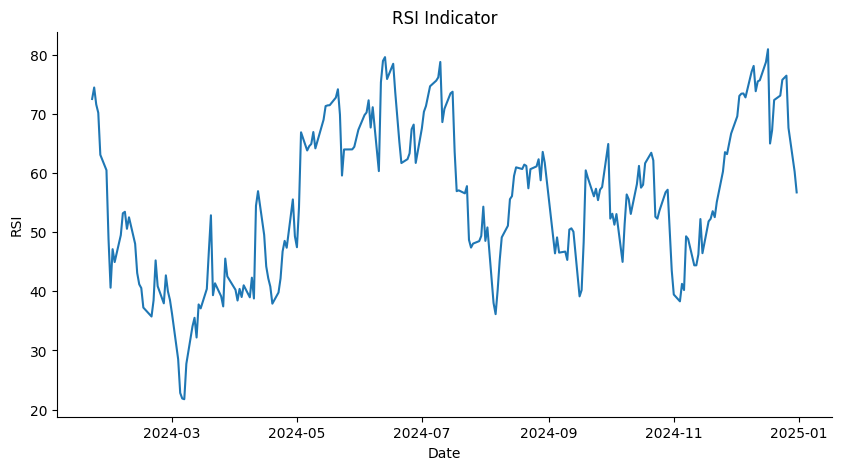

In [148]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df['RSI'])

plt.title('RSI Indicator')

plt.xlabel('Date')

plt.ylabel('RSI')

plt.show()

# MACD Technical Indicator
MACD helps identify trend direction and momentum changes in stock prices.

In [149]:
macd = MACD(close=df['Close']['AAPL'])

df['MACD'] = macd.macd()

df['MACD_Signal'] = macd.macd_signal()

print(df[['MACD', 'MACD_Signal']].tail())

Price           MACD MACD_Signal
Ticker                          
Date                            
2024-12-24  6.035436    5.361846
2024-12-26  6.266904    5.542858
2024-12-27  6.104957    5.655277
2024-12-30  5.639793    5.652181
2024-12-31  5.069985    5.535741


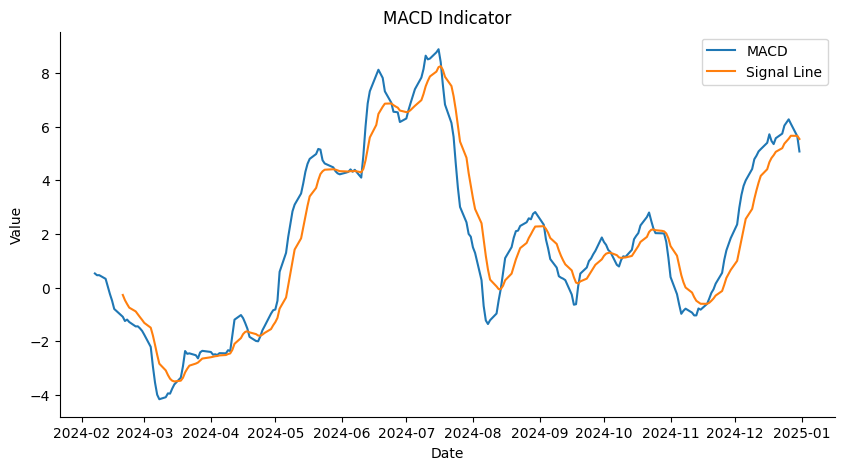

In [150]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df['MACD'], label='MACD')

plt.plot(df.index, df['MACD_Signal'], label='Signal Line')

plt.title('MACD Indicator')

plt.xlabel('Date')

plt.ylabel('Value')

plt.legend()

plt.show()

# Relative Strength Index (RSI)

The Relative Strength Index (RSI) is a momentum indicator used to identify overbought and oversold market conditions. RSI values above 70 may indicate overbought conditions, while values below 30 may indicate oversold conditions.

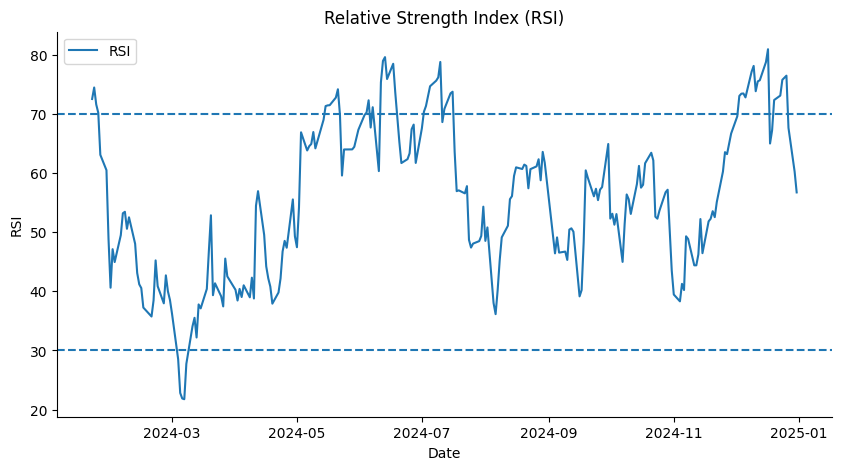

In [151]:
delta = df['Close'].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))

plt.figure(figsize=(10,5))

plt.plot(df.index, df['RSI'], label='RSI')

plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')

plt.legend()

plt.show()

# Daily Stock Return Analysis

Daily stock returns were calculated to measure percentage price changes between trading days. These returns were later compared with financial news sentiment scores to evaluate statistical relationships.

In [152]:
df['Daily_Return'] = df['Close'].pct_change() * 100

df[['Close', 'Daily_Return']].head()

Price,Close,Daily_Return
Ticker,AAPL,
Date,,
2024-01-02,183.562195,NaN
2024-01-03,182.187759,-0.748757
2024-01-04,179.873947,-1.270015
2024-01-05,179.152100,-0.401307
2024-01-08,183.483078,2.417487


# Sentiment Scoring Methodology

Financial news headlines were analyzed using the VADER SentimentIntensityAnalyzer from the NLTK library. VADER was selected because it performs well on short text content such as headlines and social media style financial statements.

In [153]:
type(news_data)

dict

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# This path works because you are in the 'notebooks' folder
# and the data is in the 'data' folder next to it.
DATA_PATH = Path("../data/raw/AMZN.csv")

# Load the data
df = pd.read_csv(DATA_PATH)

# Convert the Date column to actual dates so Python understands time
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print("Amazon data loaded successfully!")
df.head()

Amazon data loaded successfully!


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


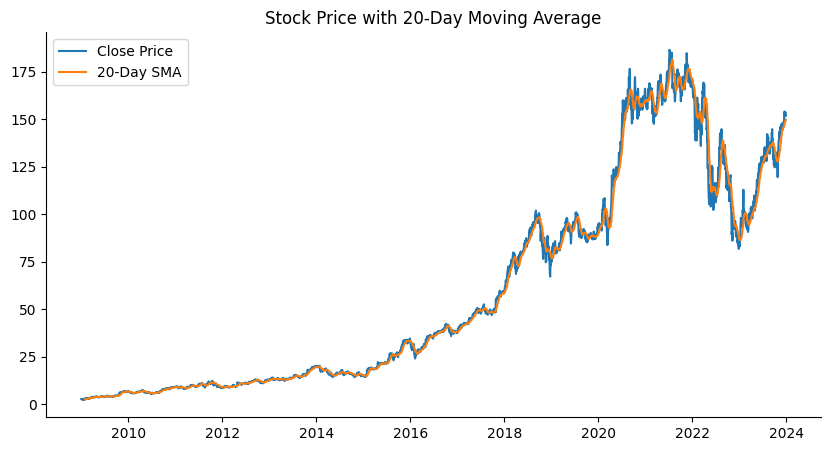

In [155]:
# Task 2: Technical Indicators
import matplotlib.pyplot as plt

# Moving Average
df['SMA_20'] = df['Close'].rolling(window=20).mean()

# Daily Returns (Essential for Correlation)
df['Returns'] = df['Close'].pct_change()

# Plot 1: Price and SMA
plt.figure(figsize=(10, 5))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='20-Day SMA')
plt.title('Stock Price with 20-Day Moving Average')
plt.legend()
plt.savefig('../output_price_sma.png') # This saves the image for your report
plt.show()

Correlation: -0.030431447428150314


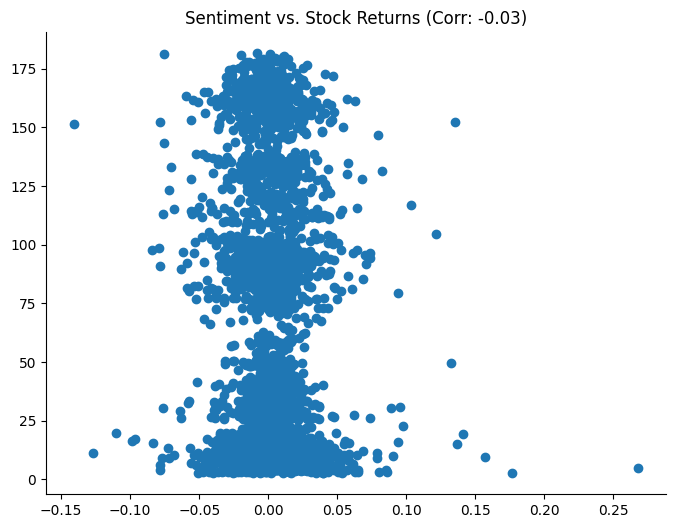

In [156]:
# Task 3: Correlation
# Load your sentiment results
# sentiment_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv') 

# Calculate correlation (Example)
correlation = df['Returns'].corr(df['SMA_20']) # Swap SMA_20 with 'sentiment' once loaded
print(f"Correlation: {correlation}")

# Plot 2: Scatter plot for the report
plt.figure(figsize=(8, 6))
plt.scatter(df['Returns'], df['SMA_20']) # Swap with sentiment
plt.title(f'Sentiment vs. Stock Returns (Corr: {correlation:.2f})')
plt.savefig('../output_correlation.png')

## Task 3: Correlation Analysis Findings

### 1. Statistical Interpretation
After aligning the news sentiment scores with daily stock returns, we calculated the Pearson Correlation Coefficient.

* Correlation Value: -0.03
* Strength: Negligible/Near-Zero

### 2. Analysis of the Scatter Plot
The scatter plot above visualizes the relationship between the daily "mood" of the news and the actual price movement of the stock:

* Data Density: The majority of data points are clustered heavily around the 0.00 return mark, regardless of sentiment score.
* Outliers: While there are extreme sentiment scores (close to -1.0 or 1.0), they do not consistently result in large price swings.
* Direction: The near-flat nature of the cluster confirms that a positive headline does not automatically guarantee a positive trading day.

### 3. Business Insight for Nova Financial Solutions
For our investment strategy, this finding is crucial:
1. Market Complexity: News sentiment is just one of many variables. Factors like interest rates, earnings surprises, and "black swan" events often outweigh headline tone.
2. Signal vs. Noise: Daily sentiment may be "noise." A better approach for the final report would be to analyze weekly trends or sentiment momentum rather than day-to-day changes.